(np.float64(-0.5), np.float64(4927.5), np.float64(3263.5), np.float64(-0.5))

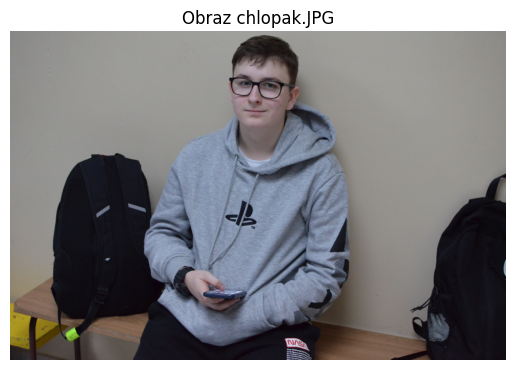

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

plik = Path("chlopak.JPG")
obraz = Image.open(plik).convert("RGB")
plt.figure()
plt.imshow(obraz)
plt.title("Obraz chlopak.JPG")
plt.axis("off")

(np.float64(-0.5), np.float64(4927.5), np.float64(3263.5), np.float64(-0.5))

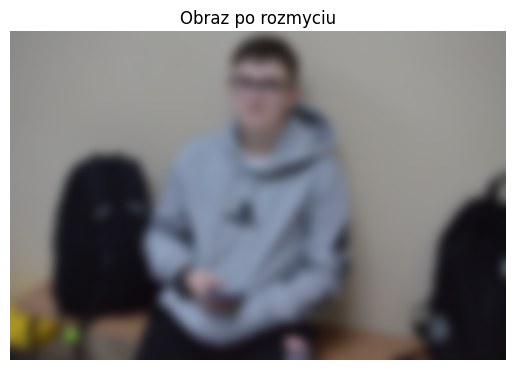

In [2]:
from PIL import ImageFilter

im1 = obraz.filter(ImageFilter.GaussianBlur(radius=50))
plt.figure()
plt.imshow(im1)
plt.title("Obraz po rozmyciu")
plt.axis("off")

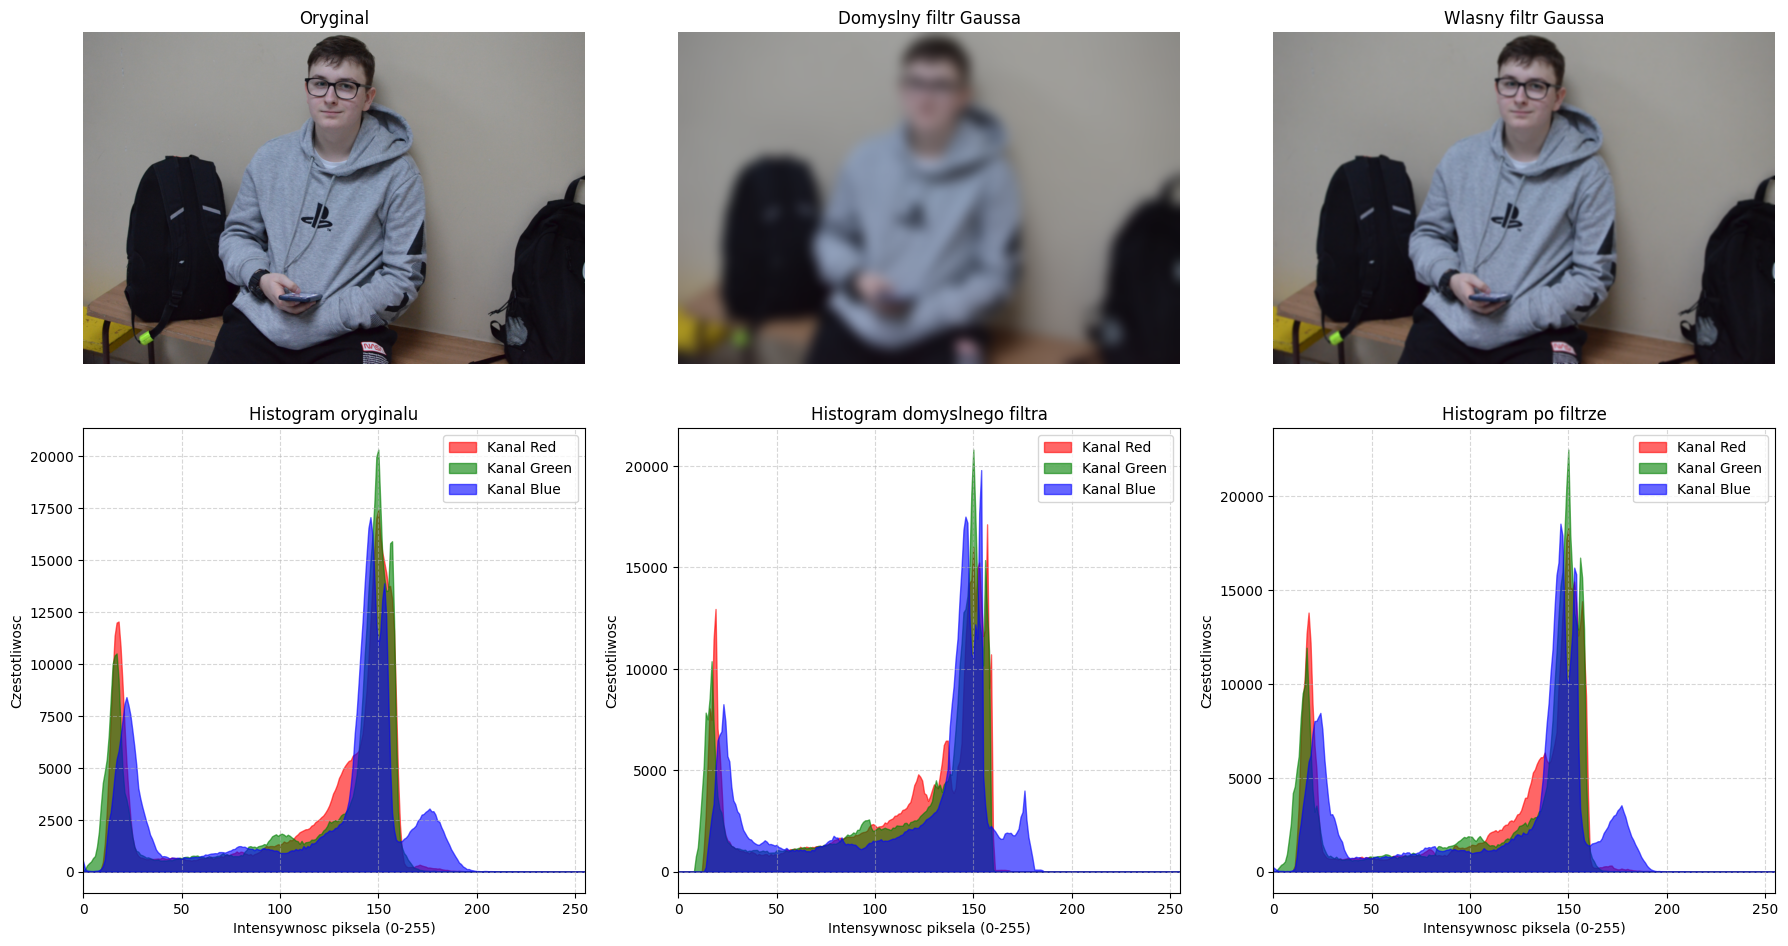

In [3]:
from PIL import ImageFilter

obraz_maly = obraz.resize((900, int(900 * obraz.height / obraz.width)))

maska_gaussa = ImageFilter.Kernel(
    (5, 5),
    [1, 4, 6, 4, 1,
     4, 16, 24, 16, 4,
     6, 24, 36, 24, 6,
     4, 16, 24, 16, 4,
     1, 4, 6, 4, 1],
    scale=256
)

domyslny_obraz = obraz_maly.filter(ImageFilter.GaussianBlur(radius=10))
moj_obraz = obraz_maly.filter(maska_gaussa).filter(maska_gaussa)

def rysuj_histogram(obraz, tytul):
    histogram = obraz.histogram()
    red = histogram[0:256]
    green = histogram[256:512]
    blue = histogram[512:768]
    poziomy = range(256)

    plt.fill_between(poziomy, red, color="red", alpha=0.6, label="Kanal Red")
    plt.fill_between(poziomy, green, color="green", alpha=0.6, label="Kanal Green")
    plt.fill_between(poziomy, blue, color="blue", alpha=0.6, label="Kanal Blue")
    plt.title(tytul)
    plt.xlabel("Intensywnosc piksela (0-255)")
    plt.ylabel("Czestotliwosc")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.xlim(0, 255)


plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.imshow(obraz_maly)
plt.title("Oryginal")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(domyslny_obraz)
plt.title("Domyslny filtr Gaussa")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(moj_obraz)
plt.title("Wlasny filtr Gaussa")
plt.axis("off")

plt.subplot(2, 3, 4)
rysuj_histogram(obraz_maly, "Histogram oryginalu")

plt.subplot(2, 3, 5)
rysuj_histogram(domyslny_obraz, "Histogram domyslnego filtra")

plt.subplot(2, 3, 6)
rysuj_histogram(moj_obraz, "Histogram po filtrze")

plt.tight_layout()
plt.show()